# Genomické jazykové modely přes MCP API

Tento notebook ukazuje, jak z Pythonu pracovat s genomickými modely, které běží na serveru jako
**MCP služby** (Model Context Protocol, streamable HTTP):

| Služba | Port | Modely |
|---|---|---|
| `ntv3-mcp` | 8000 | InstaDeep Nucleotide Transformer v3 (tokenizer po jednotlivých bázích) |
| `ntv2-mcp` | 8001 | InstaDeep Nucleotide Transformer v2 + v1 2.5B (6-merový tokenizer) |

Postup:
1. ověříme, že služby žijí, a zeptáme se jich, **jaké nástroje (tools) nabízejí**,
2. zeptáme se API, **jaké modely (checkpointy) jsou k dispozici**,
3. z **každého typu modelu vybereme jeden** (výchozí model služby, jinak ten nejmenší),
4. na každém otestujeme stejnou DNA sekvenci: embedding, podobnost sekvencí, skóre SNP
   a (kde to model umí) predikci maskované báze,
5. ukážeme extrakci embeddingů podrobněji: **dávka více sekvencí** najednou a **embedding po tokenech**.

Notebook je čistě klient -- nic se tu nestahuje ani nepočítá na GPU, vše dělá server.

## 1. Nastavení

Adresu serveru a token se předávají přes proměnné prostředí:

- `MCP_HOST` -- např. `http://kbi-cs2.fbmi.cvut.cz` (výchozí `http://localhost`, když běžíte přímo na serveru),
- `MCP_AUTH_TOKEN` -- sdílený token; server bez něj vrací `401 Unauthorized`.

Klient `GenericMcpClient` je v tomto repozitáři (`packages/dnalm-client`) a používá jen standardní
knihovnu Pythonu, takže stačí přidat jeho cestu do `sys.path` -- nic se neinstaluje.

In [1]:
import os
import random
import sys
import time
from collections import defaultdict
from pathlib import Path

try:
    from dnalm_client import GenericMcpClient
except ImportError:  # spuštěno mimo virtuální prostředí repozitáře
    repo_root = next(
        p for p in [Path.cwd(), *Path.cwd().parents] if (p / "packages" / "dnalm-client").is_dir()
    )
    sys.path.insert(0, str(repo_root / "packages" / "dnalm-client" / "src"))
    from dnalm_client import GenericMcpClient

HOST = os.environ.get("MCP_HOST", "http://localhost").rstrip("/")
TOKEN = os.environ.get("MCP_AUTH_TOKEN")
SERVICES = {
    "ntv3": f"{HOST}:8000",
    "ntv2": f"{HOST}:8001",
    "dnabert2": f"{HOST}:8002",
    "hyenadna": f"{HOST}:8003",
    "evo2": f"{HOST}:8004",
    "generator": f"{HOST}:8005",
    "genalm": f"{HOST}:8006",
    "grover": f"{HOST}:8007",
}
TIMEOUT_S = 900  # první volání nového modelu ho na serveru stahuje a načítá do GPU

clients = {
    name: GenericMcpClient(url, auth_token=TOKEN, timeout=TIMEOUT_S)
    for name, url in SERVICES.items()
}
print("server:", HOST, "| token nastaven:", bool(TOKEN))

server: http://localhost | token nastaven: True


## 2. Žije to? A co to umí?

`/health` je bez autentizace (pro healthchecky). `list_tools()` je standardní MCP požadavek `tools/list` --
každá rodina modelů nabízí trochu jinou sadu nástrojů, proto je dobré se nejdřív zeptat.

In [2]:
tools_by_service = {}
for name, client in clients.items():
    tools = client.list_tools()
    tools_by_service[name] = {t["name"] for t in tools}
    print(f"== {name} ({SERVICES[name]})  health: {client.health().strip()}")
    for t in tools:
        first_line = (t.get("description") or "").strip().splitlines()[0]
        print(f"   {t['name']:<28} {first_line}")
    print()

all_tools = set().union(*tools_by_service.values())
for tool in sorted(all_tools):
    missing = [s for s, names in tools_by_service.items() if tool not in names]
    if missing:
        print(f"'{tool}' chybí v: {', '.join(missing)}")

== ntv3 (http://localhost:8000)  health: ok
   list_available_checkpoints   List NTv3 checkpoints available as the `checkpoint` argument of the other tools.
   get_model_info               Load an NTv3 checkpoint and report its architecture details.
   get_embedding_layers         List hidden-state layer indices usable as `layer_name` in embed_sequence.
   embed_sequence               Return NTv3 feature representations (embeddings) for one or more DNA sequences.
   score_snp                    Zero-shot effect score for a single-nucleotide substitution.
   predict_masked_positions     Predict nucleotide probabilities at masked positions in a DNA sequence.
   compare_sequences            Compute cosine similarity between the mean-pooled NTv3 embeddings of two DNA sequences.
   list_species                 List the species a post-trained checkpoint is conditioned on, and what it can predict.
   list_tracks                  List the experimental track ids predict_tracks accepts for a spe

`predict_masked_positions` má jen NTv3: jeho tokenizer je 1 báze = 1 token, takže lze zamaskovat
jednu konkrétní pozici. NTv2 tokenizuje po 6-merech, tam „jedna pozice“ neodpovídá jednomu tokenu.

## 3. Jaké modely jsou k dispozici?

In [3]:
checkpoints = {name: client.list_available_checkpoints() for name, client in clients.items()}

for name, cks in checkpoints.items():
    print(f"== {name}: {len(cks)} checkpointů")
    for ck in cks:
        typ = ck.get("stage") or ck.get("generation")
        ctx = ck.get("context") or f"{ck.get('max_tokens')} tokenů"
        default = "  <- výchozí" if ck.get("default") else ""
        print(
            f"   {ck['name']:<16} typ={typ:<5} parametry={ck['params']:<6} kontext={ctx}{default}"
        )
    print()

== ntv3: 14 checkpointů
   8m-pre           typ=pre   parametry=7.7M   kontext=full (~1Mb)
   8m-pre-8kb       typ=pre   parametry=7.7M   kontext=8kb
   100m-pre         typ=pre   parametry=0.1B   kontext=full (~1Mb)  <- výchozí
   100m-pre-8kb     typ=pre   parametry=0.1B   kontext=8kb
   100m-post        typ=post  parametry=0.1B   kontext=full (~1Mb)
   100m-post-131kb  typ=post  parametry=0.1B   kontext=131kb
   650m-pre         typ=pre   parametry=0.7B   kontext=full (~1Mb)
   650m-pre-8kb     typ=pre   parametry=0.7B   kontext=8kb
   650m-post        typ=post  parametry=0.7B   kontext=full (~1Mb)
   650m-post-131kb  typ=post  parametry=0.7B   kontext=131kb
   5ds-pre          typ=pre   parametry=0.6B   kontext=full (~1Mb)
   5ds-pre-8kb      typ=pre   parametry=0.6B   kontext=8kb
   5ds-post         typ=post  parametry=0.6B   kontext=full (~1Mb)
   5ds-post-131kb   typ=post  parametry=0.6B   kontext=131kb

== ntv2: 5 checkpointů
   50m              typ=v2    parametry=50M    konte

## 4. Z každého typu vybereme jeden model

„Typ“ je u NTv3 fáze tréninku (`stage`: `pre` = předtrénovaný, `post` = dotrénovaný na funkčních
genomických datech, `base`), u NTv2 generace (`generation`: `v2`, `v1`). Z každé skupiny vezmeme
výchozí model služby (`default: true`), pokud do ní patří, jinak model s nejmenším počtem parametrů.

Proč ne vždy ten nejmenší: např. NTv3 `8m-pre` má v embeddingu několik obřích „outlier“ dimenzí
(hodnoty ~1000 proti mediánu ~0.2), takže kosinová podobnost je u něj ~1.0 pro cokoli.

In [4]:
def params_to_number(params: str) -> float:
    """'7.7M' -> 7.7e6, '0.1B' -> 1e8; neznámé ('-') řadí na konec."""
    units = {"K": 1e3, "M": 1e6, "B": 1e9}
    try:
        return float(params[:-1]) * units[params[-1].upper()]
    except (ValueError, KeyError, IndexError):
        return float("inf")


groups = defaultdict(list)
for service, cks in checkpoints.items():
    for ck in cks:
        groups[(service, ck.get("stage") or ck.get("generation"))].append(ck)

picks = []
for (service, typ), cks in groups.items():
    default = next((ck for ck in cks if ck.get("default")), None)
    chosen = default or min(
        cks, key=lambda ck: params_to_number(ck["params"])
    )  # při shodě první v pořadí API
    reason = "výchozí" if default else "nejmenší"
    picks.append(
        {"service": service, "type": typ, "checkpoint": chosen["name"], "params": chosen["params"]}
    )
    print(
        f"{service}/{typ:<5} -> {chosen['name']:<10} ({chosen['params']}, {reason}, vybráno z {len(cks)})"
    )

ntv3/pre   -> 100m-pre   (0.1B, výchozí, vybráno z 8)
ntv3/post  -> 100m-post  (0.1B, nejmenší, vybráno z 6)
ntv2/v2    -> 500m       (500M, výchozí, vybráno z 4)
ntv2/v1    -> 2.5b-v1    (2.5B, nejmenší, vybráno z 1)


## 5. Testovací sekvence

Začátek kódující sekvence lidského genu **HBB** (β-globin, exon 1) a v něm varianta, která způsobuje
srpkovitou anémii: kodon 6 `GAG` → `GTG` (Glu → Val), tj. `A` → `T` na pozici 19 (číslováno od 0).
Jako negativní kontrolu přidáme náhodnou sekvenci stejné délky.

> Je to jen ilustrace volání API. Zero-shot skóre z jazykového modelu **není** klinická predikce.

In [5]:
HBB = "ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAGTTGGTGGTGAGGCCCTGGGCAG"
SNP_POS, SNP_ALT = 19, "T"
HBB_SICKLE = HBB[:SNP_POS] + SNP_ALT + HBB[SNP_POS + 1 :]
random.seed(42)
RANDOM_SEQ = "".join(random.choice("ACGT") for _ in HBB)

print(f"délka: {len(HBB)} bp")
print("kodony 1-7 ref:", " ".join(HBB[i : i + 3] for i in range(0, 21, 3)))
print("kodony 1-7 alt:", " ".join(HBB_SICKLE[i : i + 3] for i in range(0, 21, 3)))

délka: 92 bp
kodony 1-7 ref: ATG GTG CAC CTG ACT CCT GAG
kodony 1-7 alt: ATG GTG CAC CTG ACT CCT GTG


## 6. Test každého vybraného modelu

Pro každý model zavoláme:

- `get_model_info` -- velikost a architektura (první volání model na serveru načte do GPU),
- `embed_sequence` -- jeden vektor pro celou sekvenci (průměr přes tokeny),
- `compare_sequences` -- kosinová podobnost embeddingů: HBB vs. HBB s mutací a HBB vs. náhodná sekvence,
- `score_snp` -- zero-shot skóre varianty (záporné = model považuje mutaci za méně pravděpodobnou),
- `predict_masked_positions` -- jen kde server nástroj nabízí: zamaskujeme pozici 19 (`N`)
  a necháme model hádat, co tam patří.

Chyby se zachytí, ať jeden nefunkční model nezastaví zbytek.

In [6]:
def test_model(service: str, checkpoint: str) -> dict:
    c = clients[service]
    row = {"service": service, "checkpoint": checkpoint}
    t0 = time.time()
    try:
        info = c.get_model_info(checkpoint=checkpoint)
        row["parametry"] = f"{info['num_parameters'] / 1e6:.0f}M"
        row["dim"] = info["hidden_size"]

        emb = c.embed_sequence(HBB, checkpoint=checkpoint)["embedding"]
        row["emb[:3]"] = [round(x, 3) for x in emb[:3]]

        row["cos(ref,mut)"] = c.compare_sequences(HBB, HBB_SICKLE, checkpoint=checkpoint)[
            "cosine_similarity"
        ]
        row["cos(ref,rnd)"] = c.compare_sequences(HBB, RANDOM_SEQ, checkpoint=checkpoint)[
            "cosine_similarity"
        ]

        snp = c.score_snp(HBB, SNP_ALT, checkpoint=checkpoint, position=SNP_POS)
        row["snp_delta"] = snp["score_delta"]
        row["snp_metoda"] = snp["method"]

        if "predict_masked_positions" in tools_by_service[service]:
            masked = HBB[:SNP_POS] + "N" + HBB[SNP_POS + 1 :]
            pred = c.predict_masked_positions(masked, checkpoint=checkpoint, top_k=2)
            top = pred["predictions"][0]["predictions"]
            row["maskovaná_pozice_19"] = ", ".join(
                f"{p['nucleotide']}={p['probability']:.2f}" for p in top
            )
        else:
            row["maskovaná_pozice_19"] = "(nástroj není k dispozici)"
        row["stav"] = "OK"
    except Exception as exc:  # noqa: BLE001 - chceme pokračovat dalším modelem
        row["stav"] = f"CHYBA: {exc}"
    row["čas_s"] = round(time.time() - t0, 1)
    return row


results = []
for pick in picks:
    print(f"testuji {pick['service']}/{pick['checkpoint']} ...", flush=True)
    results.append({"typ": pick["type"], **test_model(pick["service"], pick["checkpoint"])})
print("hotovo")

testuji ntv3/100m-pre ...


testuji ntv3/100m-post ...


testuji ntv2/500m ...


testuji ntv2/2.5b-v1 ...


hotovo


## 7. Souhrn

In [7]:
columns = [
    "service",
    "typ",
    "checkpoint",
    "stav",
    "parametry",
    "dim",
    "cos(ref,mut)",
    "cos(ref,rnd)",
    "snp_delta",
    "maskovaná_pozice_19",
    "čas_s",
]


def fmt(col, value):
    if isinstance(value, float):
        return f"{value:.1f}" if col == "čas_s" else f"{value:.4f}"
    return "" if value is None else str(value)


table = [[fmt(col, r.get(col)) for col in columns] for r in results]
widths = [max(len(col), *(len(row[i]) for row in table)) for i, col in enumerate(columns)]
print("  ".join(col.ljust(w) for col, w in zip(columns, widths)))
print("  ".join("-" * w for w in widths))
for row in table:
    print("  ".join(cell.ljust(w) for cell, w in zip(row, widths)))

print()
for r in results:
    if r.get("snp_metoda"):
        print(f"{r['service']}/{r['checkpoint']}: score_snp metoda = {r['snp_metoda']}")

service  typ   checkpoint  stav  parametry  dim   cos(ref,mut)  cos(ref,rnd)  snp_delta  maskovaná_pozice_19         čas_s
-------  ----  ----------  ----  ---------  ----  ------------  ------------  ---------  --------------------------  -----
ntv3     pre   100m-pre    OK    106M       768   0.9997        0.9829        -0.5653    A=0.48, T=0.27              3.3  
ntv3     post  100m-post   OK    120M       768   0.9908        0.4108        1.2607     T=0.55, G=0.22              2.8  
ntv2     v2    500m        OK    498M       1024  0.9936        0.9301        -0.1630    (nástroj není k dispozici)  1.9  
ntv2     v1    2.5b-v1     OK    2548M      2560  0.9969        0.8880        -1.4429    (nástroj není k dispozici)  12.1 

ntv3/100m-pre: score_snp metoda = single_position_masked_lm_log_prob
ntv3/100m-post: score_snp metoda = single_position_masked_lm_log_prob
ntv2/500m: score_snp metoda = whole_sequence_log_prob_delta
ntv2/2.5b-v1: score_snp metoda = whole_sequence_log_prob_delta

### Jak výsledky číst

- **Embeddingy** mají u každého modelu jinou dimenzi a nejsou mezi modely srovnatelné.
- **Kosinová podobnost** vychází u těchto modelů vysoká skoro pro cokoli (embeddingy leží v úzkém kuželu),
  takže má smysl hlavně *relativní* srovnání: mutace o 1 bázi by měla být blíž originálu než náhodná sekvence.
  Pro vyhledávání/shlukování je lepší embeddingy nad celým datasetem nejdřív vycentrovat a standardizovat.
- **`score_snp`** -- pozor na pole `method`:
  - NTv3 (`single_position_masked_lm_log_prob`): zamaskuje jednu pozici a porovná log-pravděpodobnost
    alternativní vs. referenční báze,
  - NTv2 (`whole_sequence_log_prob_delta`): spočte pseudo-log-likelihood celé referenční a celé mutované
    sekvence a vrátí rozdíl.

  Čísla z různých metod (a různých modelů) se proto **nedají přímo porovnávat**; srovnávejte varianty
  v rámci jednoho modelu.
- **NTv3 `post`** checkpointy jsou podmíněné **druhem organismu**: parametr `species`, výchozí `human`
  (seznam vrací `list_species`). U `pre` checkpointů se `species` nezadává. Kromě embeddingů umí
  `post` modely i anotaci genomu a predikci experimentálních signálů -- viz sekce 9.

## 8. Extrakce embeddingů podrobněji

`embed_sequence` má tři podoby:

| Volání | Výsledek |
|---|---|
| `embed_sequence("ACGT...")` | `embedding`: jeden vektor (průměr přes tokeny, `pooling="mean"`) |
| `embed_sequence(["ACGT...", "GGCC...", ...])` | `embeddings`: seznam vektorů, **jedna dávka = jeden forward pass** na GPU |
| `embed_sequence("ACGT...", pooling="per_token")` | `embedding`: matice *tokeny × dimenze* |

Dávka je rychlejší než volat sekvence po jedné (jedna síťová cesta, jeden průchod modelem).
Sekvence v dávce můžou mít různou délku -- server je doplní (padding) a průměr počítá jen přes skutečné tokeny.
Každá sekvence ale musí splnit limit kontextu modelu.

U `per_token` záleží na tokenizeru: NTv3 má 1 token = 1 báze, NTv2 má `<cls>` + 6-mery
(+ zbylé báze po jedné), takže řádků je zhruba délka/6.

In [8]:
batch = [HBB, HBB_SICKLE, RANDOM_SEQ, HBB[:60]]  # různé délky jsou v pořádku
working = [r for r in results if r["stav"] == "OK"]

for r in working:
    c, ck = clients[r["service"]], r["checkpoint"]

    t0 = time.time()
    out = c.embed_sequence(batch, checkpoint=ck)
    t_batch = time.time() - t0

    t0 = time.time()
    singles = [c.embed_sequence(s, checkpoint=ck)["embedding"] for s in batch]
    t_single = time.time() - t0
    max_diff = max(abs(a - b) for e1, e2 in zip(out["embeddings"], singles) for a, b in zip(e1, e2))

    per_token = c.embed_sequence(HBB, checkpoint=ck, pooling="per_token")["embedding"]

    print(f"== {r['service']}/{ck}")
    print(
        f"   dávka: {len(out['embeddings'])} sekvencí x {len(out['embeddings'][0])} dim "
        f"za {t_batch:.2f} s (po jedné: {t_single:.2f} s), max. rozdíl dávka vs. po jedné = {max_diff:.1e}"
    )
    print(f"   per_token pro {len(HBB)} bp: {len(per_token)} řádků x {len(per_token[0])} dim")

== ntv3/100m-pre
   dávka: 4 sekvencí x 768 dim za 0.04 s (po jedné: 0.09 s), max. rozdíl dávka vs. po jedné = 1.9e-04
   per_token pro 92 bp: 92 řádků x 768 dim


== ntv3/100m-post
   dávka: 4 sekvencí x 768 dim za 0.04 s (po jedné: 0.14 s), max. rozdíl dávka vs. po jedné = 6.9e-03
   per_token pro 92 bp: 92 řádků x 768 dim
== ntv2/500m
   dávka: 4 sekvencí x 1024 dim za 0.04 s (po jedné: 0.12 s), max. rozdíl dávka vs. po jedné = 2.4e-06
   per_token pro 92 bp: 18 řádků x 1024 dim


== ntv2/2.5b-v1
   dávka: 4 sekvencí x 2560 dim za 0.06 s (po jedné: 0.11 s), max. rozdíl dávka vs. po jedné = 9.5e-06
   per_token pro 92 bp: 18 řádků x 2560 dim


Malý rozdíl mezi dávkou a voláním po jedné (řádově 1e-6 až 1e-4) je numerický šum výpočtu
v plovoucí čárce s jinak velkou maticí, ne chyba.

Mezivrstvy NTv3 (`layer_name` mezi první a poslední) mají kvůli U-Net architektuře nižší rozlišení --
`get_embedding_layers(checkpoint, which="all")` vrací u každé vrstvy `bases_per_position`.

## 9. NTv3 `post`: anotace genomu

Post-trained NTv3 modely byly doučené na funkčních datech o genomu, proto potřebují vědět, **z jakého
organismu** sekvence je (`species`). Pak umí pro každou bázi předpovědět, jestli leží v genu, exonu,
intronu, promotoru, UTR atd. (`annotate_sequence`, 21 tříd) a odhadnout experimentální signály
(`predict_tracks`: RNA-seq, ChIP-seq, ATAC, CAGE... -- u člověka 7362 tracků).

Predikce pokrývá jen **prostředních 37,5 %** vstupního okna, zbytek slouží jako kontext. Proto
pošleme 32 kb okno z lidského genomu (hg38, UCSC API) se středem na genu *HBB* a podíváme se,
jestli model najde jeho tři exony.

In [9]:
import json
import urllib.request

ntv3 = clients["ntv3"]
# Nástroje specifické pro jeden model (tady NTv3) se volají obecně: client.call("název", **argumenty)
species = ntv3.call("list_species", checkpoint="100m-post")["species"]
print(len(species), "druhů, s tracky:", [s["name"] for s in species if s["num_tracks"]])

# HBB (hg38, minus strand): chr11:5,225,464-5,227,071 -> 32 kb okno se středem na genu
CHROM, GENE_START, GENE_END = "chr11", 5_225_464, 5_227_071
center = (GENE_START + GENE_END) // 2
WIN_START, WIN_END = center - 16_384, center + 16_384
url = f"https://api.genome.ucsc.edu/getData/sequence?genome=hg38;chrom={CHROM};start={WIN_START};end={WIN_END}"
with urllib.request.urlopen(url, timeout=60) as resp:
    window = json.load(resp)["dna"].upper()
print(f"{CHROM}:{WIN_START:,}-{WIN_END:,} -> {len(window):,} bp")

BIN = 16
ann = ntv3.call(
    "annotate_sequence",
    sequence=window,
    checkpoint="100m-post",
    species="human",
    bin_size=BIN,
    elements=["protein_coding_gene", "exon", "intron", "3UTR-"],
)
print(
    f"predikovaný úsek okna: {ann['region_start']}-{ann['region_end']} (bin {ann['bin_size']} bp)"
)
print("max. pravděpodobnost:", ann["max_probability"])

24 druhů, s tracky: ['arabidopsis_thaliana', 'drosophila_melanogaster', 'glycine_max', 'gossypium_hirsutum', 'human', 'mouse', 'oryza_sativa', 'triticum_aestivum', 'zea_mays']


chr11:5,209,883-5,242,651 -> 32,768 bp


predikovaný úsek okna: 10240-22528 (bin 16 bp)
max. pravděpodobnost: {'protein_coding_gene': 0.9958, 'exon': 0.9516, 'intron': 0.9763, '3UTR-': 0.8692}


Graf pravděpodobností v genomových souřadnicích. Šedé pruhy jsou skutečné exony HBB podle anotace
hg38 -- model je nezná, vidí jen DNA a druh organismu.

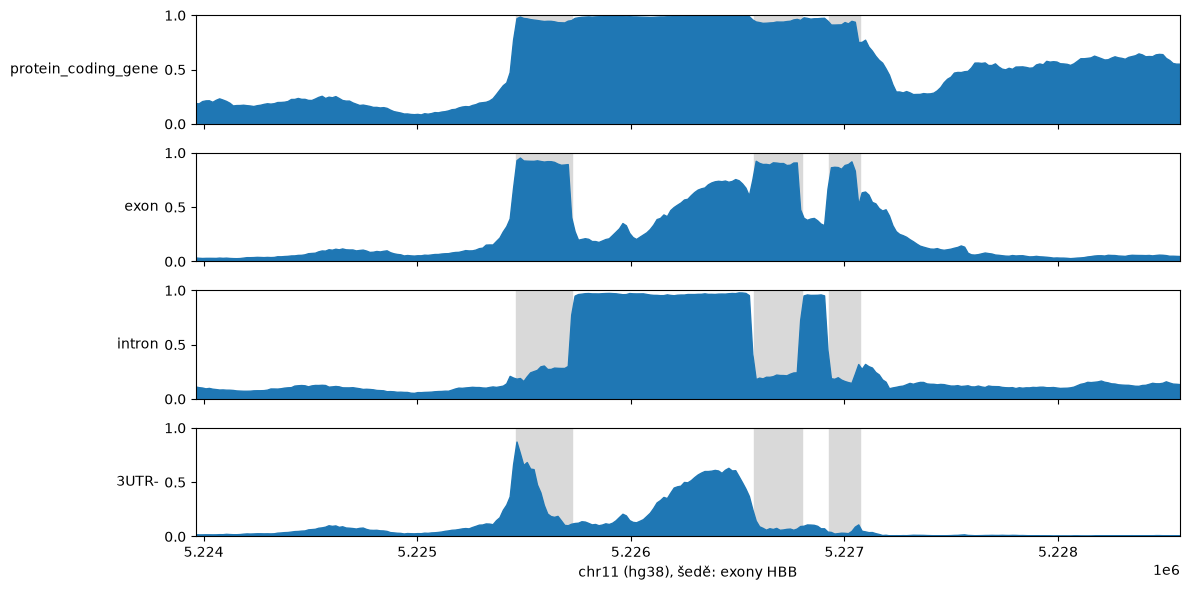

exon 3         exon=0.89  intron=0.28
intron 2       exon=0.45  intron=0.96
exon 2         exon=0.87  intron=0.25
exon 1         exon=0.83  intron=0.19
5 kb mimo gen  exon=0.03  intron=0.08


In [10]:
HBB_EXONS = [(5_225_464, 5_225_726), (5_226_577, 5_226_799), (5_226_930, 5_227_071)]  # hg38
x = [WIN_START + ann["region_start"] + i * BIN for i in range(len(ann["probabilities"]["exon"]))]

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
    for ax, elem in zip(axes, ["protein_coding_gene", "exon", "intron", "3UTR-"]):
        for lo, hi in HBB_EXONS:
            ax.axvspan(lo, hi, color="0.85")
        ax.fill_between(x, ann["probabilities"][elem], color="tab:blue")
        ax.set_ylim(0, 1)
        ax.set_ylabel(elem, rotation=0, ha="right", va="center")
    axes[-1].set_xlim(GENE_START - 1500, GENE_END + 1500)
    axes[-1].set_xlabel(f"{CHROM} (hg38), šedě: exony HBB")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("(matplotlib není nainstalovaný -- jen textový souhrn)")


def mean_prob(elem, lo, hi):
    vals = [p for xi, p in zip(x, ann["probabilities"][elem]) if lo <= xi < hi]
    return sum(vals) / len(vals)


for name, (lo, hi) in [
    ("exon 3", HBB_EXONS[0]),
    ("intron 2", (HBB_EXONS[0][1] + 50, HBB_EXONS[1][0] - 50)),
    ("exon 2", HBB_EXONS[1]),
    ("exon 1", HBB_EXONS[2]),
    ("5 kb mimo gen", (GENE_END + 4000, GENE_END + 5000)),
]:
    print(
        f"{name:14s} exon={mean_prob('exon', lo, hi):.2f}  intron={mean_prob('intron', lo, hi):.2f}"
    )

## 10. Ukázka chybové hlášky

NTv2 má pevný limit kontextu (2048 tokenů ≈ 12 kb). Delší sekvenci server odmítne se srozumitelnou
chybou místo tichého oříznutí:

In [11]:
try:
    clients["ntv2"].embed_sequence("ACGTAC" * 2100, checkpoint="50m")
except RuntimeError as exc:
    print(exc)

Error executing tool embed_sequence: Sequence 0 tokenizes to 2101 tokens, above this checkpoint's 2048-token context limit (roughly 12282 bp of N-free sequence; each 'N' costs a whole token). Sequences are never truncated -- split it into shorter windows.


## 11. Bez Pythonu: holé HTTP volání

MCP je JSON-RPC přes HTTP, takže stačí `curl` (nebo cokoli jiného). Nejdřív se otevře session,
pak se volají nástroje s hlavičkou `Mcp-Session-Id` (ověřeno proti běžícímu serveru):

```bash
URL="$MCP_HOST:8001/mcp"
HDR=(-H "Authorization: Bearer $MCP_AUTH_TOKEN" -H "Content-Type: application/json"
     -H "Accept: application/json, text/event-stream")

# 1) initialize -> session id comes back in the "mcp-session-id" response header
SID=$(curl -si "$URL" "${HDR[@]}" -d '{"jsonrpc":"2.0","id":1,"method":"initialize",
  "params":{"protocolVersion":"2025-06-18","capabilities":{},"clientInfo":{"name":"curl","version":"1"}}}' \
  | grep -i '^mcp-session-id:' | cut -d' ' -f2 | tr -d '\r')
curl -s "$URL" "${HDR[@]}" -H "Mcp-Session-Id: $SID" -d '{"jsonrpc":"2.0","method":"notifications/initialized"}'

# 2) call a tool
curl -s "$URL" "${HDR[@]}" -H "Mcp-Session-Id: $SID" -d '{"jsonrpc":"2.0","id":2,"method":"tools/call",
  "params":{"name":"embed_sequence","arguments":{"sequence":"ACGTACGTACGT","checkpoint":"50m"}}}'
```

Odpověď přichází jako Server-Sent Events (`data: {...}`). Kompletní Python implementace (~150 řádků,
jen standardní knihovna) je v `packages/dnalm-client/src/dnalm_client/base.py`.